# Pipeline: Reset & Populate

In [ ]:
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")

from main import reset_data_file, save_graph
from populate import populate_all
from enrich import enrich_all
from reasoning import check_consistency
from graph_embedding import (
    load_object_property_triples,
    train_embedding_model,
    visualize_embeddings,
    build_entity_type_map,
    filter_predictions_by_class,
    TOP_K_PREDICTIONS,
)
from config import ONT
from graph_utils import local_name
from pykeen.predict import predict_target
from visualize import main as run_visualize


In [2]:
graph = reset_data_file()
populate_all(graph)

[Province]
  + East_Nusa_Tenggara
  + West_Nusa_Tenggara
  + Bali
[Island]
  + Nusa_Penida  (locatedIn: Bali)
  + Nusa_Lembongan  (locatedIn: Bali)
  + Serangan_Island  (locatedIn: Bali)
  + Menjangan_Island  (locatedIn: Bali)
  + Nusa_Ceningan  (locatedIn: Bali)
  -> Bali: 5 islands
  + Moyo_Island  (locatedIn: West_Nusa_Tenggara)
  + Lombok  (locatedIn: West_Nusa_Tenggara)
  + Satonda_Island  (locatedIn: West_Nusa_Tenggara)
  + Bungin_Island  (locatedIn: West_Nusa_Tenggara)
  -> NTB: 4 islands
  + Flores  (locatedIn: East_Nusa_Tenggara)
  + Komodo__island_  (locatedIn: East_Nusa_Tenggara)
  + Rote_Island  (locatedIn: East_Nusa_Tenggara)
  + Pamana_Island  (locatedIn: East_Nusa_Tenggara)
  + Besar_Island__Flores  (locatedIn: East_Nusa_Tenggara)
  + Dambila  (locatedIn: East_Nusa_Tenggara)
  + Pantar  (locatedIn: East_Nusa_Tenggara)
  + Palu_e  (locatedIn: East_Nusa_Tenggara)
  + Ndao_Island  (locatedIn: East_Nusa_Tenggara)
  + Dana_Island__Sabu_Raijua_  (locatedIn: East_Nusa_Tenggara)

# Enrich, Save, Reason

In [3]:
enrich_all(graph)
save_graph(graph)
check_consistency()

  Country backbone: 3 provinces -> Indonesia
  Added Bali_Island (manual — DBpedia has Bali as Province)
  Island -> Province: 23 links (auto from DBpedia)
  wikiPageWikiLink -> locatedIn: 204 links (auto)
  Created 8 Activity individuals
  hasActivity: 30 links (auto from categories + wikiLinks)
  Default activities (fallback): 44 links
  hasTouristAttraction (hub): 49 links
  hasAccommodation (hub): 5 links
  Komodo_National_Park -> numberOfVisitors: 45000
  Kelimutu_National_Park -> numberOfVisitors: 12507
  Mount_Rinjani_National_Park -> numberOfVisitors: 117715
  West_Bali_National_Park -> numberOfVisitors: 5592
  numberOfVisitors: 4 values added
  hasRating: 28 values added
  hasRating skipped (Hotel domain conflict): Amankila, Tandjung_Sari, Tjampuhan_Hotel, InterContinental_Hotel_Bali, Belmond_Jimbaran_Puri
  hasEntryFee: 15 values added
  hasEntryFee skipped (not in graph): Bali_Bird_Park, Sacred_Monkey_Forest_Sanctuary, Bali_Botanic_Garden
  establishedYear: 6 values added
  

True

# Graph Embedding

In [ ]:
%matplotlib inline

emb_graph, base_triples = load_object_property_triples()
training_result, triples_factory = train_embedding_model(base_triples)
entity_type_map = build_entity_type_map(emb_graph)


Saved cluster plot -> embedding_clusters.png


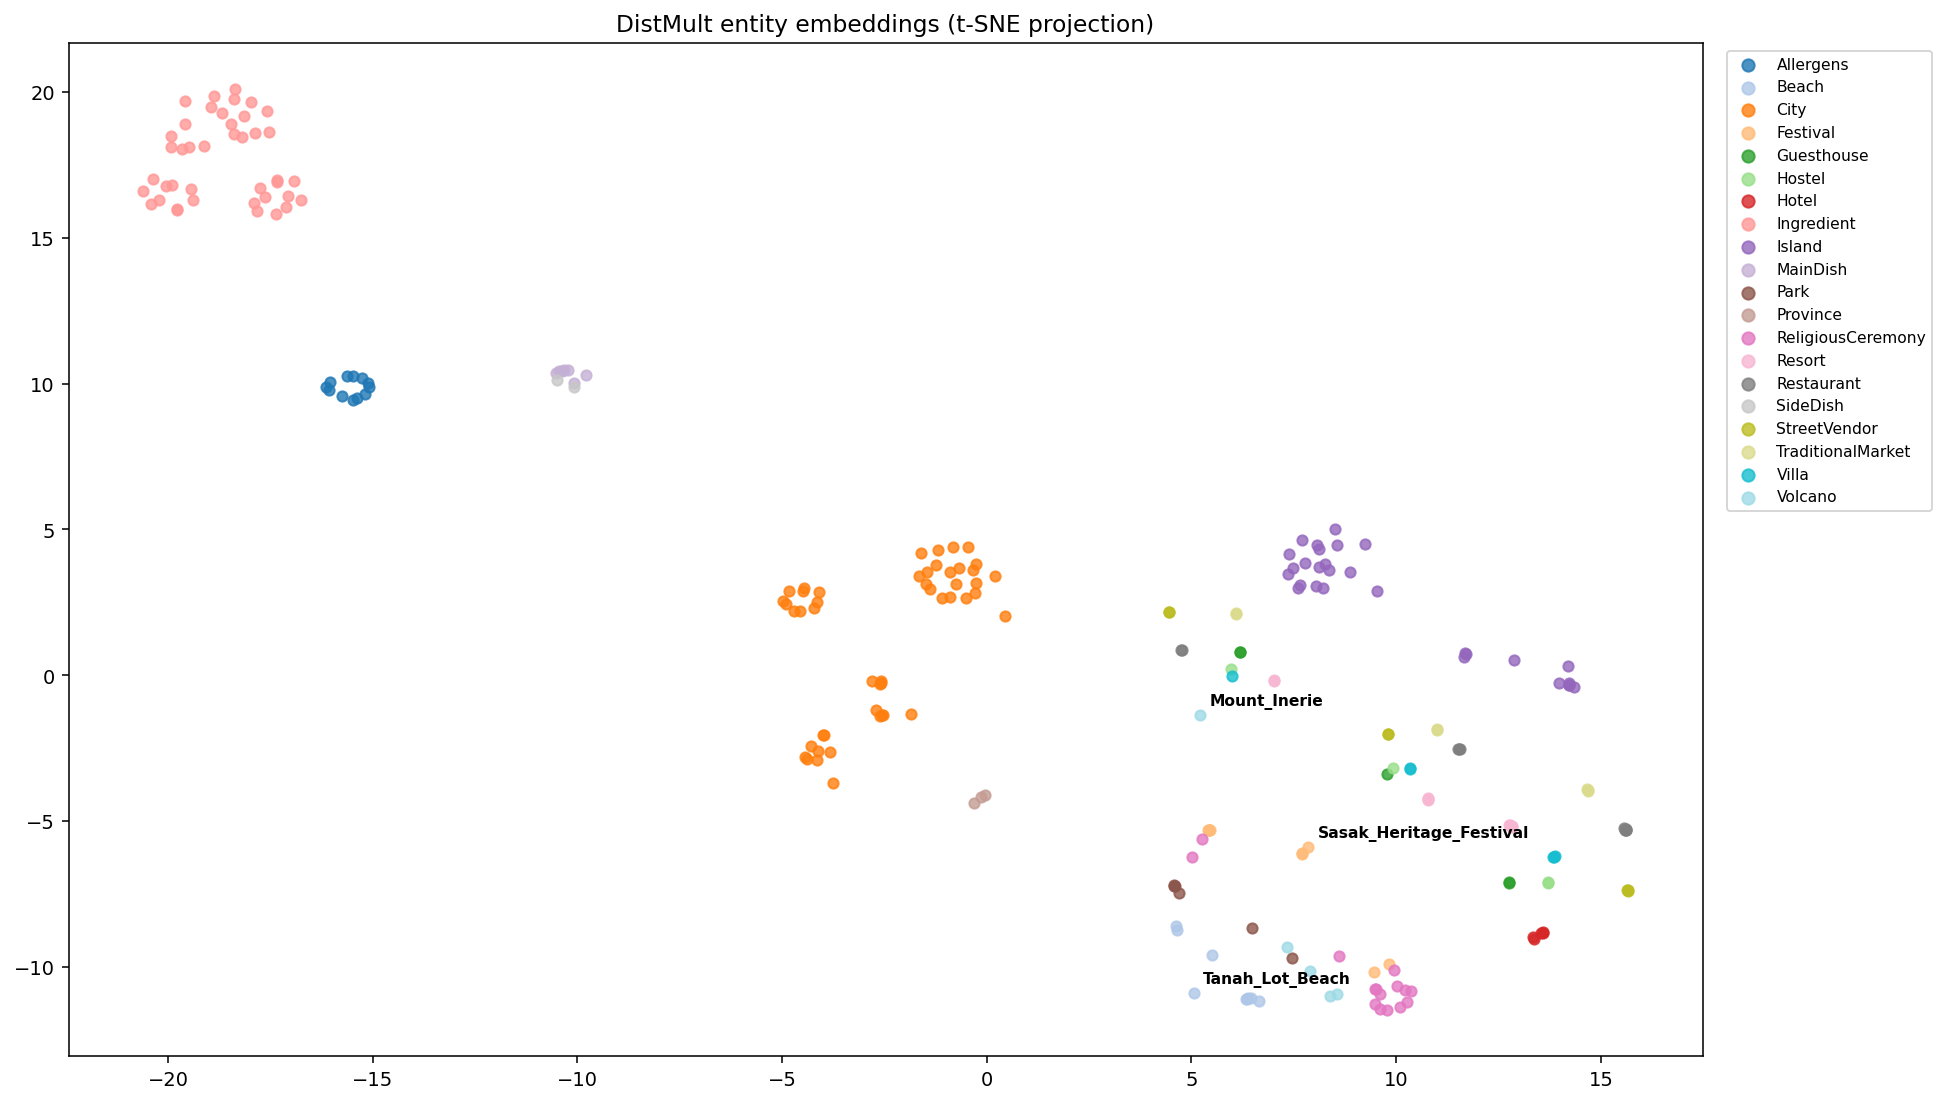

In [5]:
visualize_embeddings(training_result.model, triples_factory, emb_graph)

from IPython.display import Image, display
display(Image(filename="embedding_clusters.png"))

# Link Prediction

Change `head`, `relation`, and `expected_class` below, then re-run the cell.

In [22]:
# ── Define as many queries as you like, then re-run this cell ──
# (head, relation, expected_class)
queries = [
    ("Wainyapu__Sumba",   "locatedIn",   "Province"),
    ("Pandawa_Beach",     "locatedIn",   "City"),
    ("Barong_Dance",      "locatedIn",   "Province"),
    ("Locavore",          "locatedIn",   "Province"),
    ("Kecak",             "hasActivity", "Activities"),
]
# ─────────────────────────────────────────────────────────────────

for head, relation, expected_class in queries:
    head_iri     = str(ONT[head])
    relation_iri = str(ONT[relation])

    print(f"{head}  --{relation}-->  ?   [filtered to {expected_class}]")

    if head_iri not in triples_factory.entity_to_id:
        print(f"  '{head}' is not in the training data")
        continue
    if relation_iri not in triples_factory.relation_to_id:
        print(f"  '{relation}' is not a known relation")
        continue

    raw   = predict_target(
        model=training_result.model, head=head_iri,
        relation=relation_iri, triples_factory=triples_factory,
    ).df
    valid = filter_predictions_by_class(raw, expected_class, entity_type_map)

    if valid.empty:
        print(f"  no {expected_class} candidates found")
        continue

    print(f"{"Score":>10}  Candidate")
    print("-" * 36)

    for _, row in valid.head(TOP_K_PREDICTIONS).iterrows():
        print(f"{row["score"]:10.4f}  {local_name(row["tail_label"])}")
    best = valid.iloc[0]
    
    print(f">> Best: {local_name(best["tail_label"])} ({best["score"]:.4f})")


Wainyapu__Sumba  --locatedIn-->  ?   [filtered to Province]


NameError: name 'filter_predictions_by_class' is not defined

# Save Predictions
Review the output above, then run this cell to write the best predictions to .

In [ ]:
from rdflib import URIRef

# Collect the best prediction for each valid query
to_save = []
for head, relation, expected_class in queries:
    head_iri     = str(ONT[head])
    relation_iri = str(ONT[relation])
    if head_iri not in triples_factory.entity_to_id: continue
    if relation_iri not in triples_factory.relation_to_id: continue
    raw   = predict_target(
        model=training_result.model, head=head_iri,
        relation=relation_iri, triples_factory=triples_factory,
    ).df
    valid = filter_predictions_by_class(raw, expected_class, entity_type_map)
    if not valid.empty:
        best_iri = valid.iloc[0]["tail_label"]
        to_save.append((head_iri, relation_iri, best_iri))

# Write to emb_graph and save data.owl
for s, p, o in to_save:
    emb_graph.add((URIRef(s), URIRef(p), URIRef(o)))
    print(f"  + {local_name(s)}  --{local_name(p)}-->  {local_name(o)}")

from config import DATA_FILE
emb_graph.serialize(destination=str(DATA_FILE), format="xml")
print(f"Saved {len(to_save)} triple(s) to data.owl")

# Network Visualization

In [17]:
run_visualize()

Nodes: 312  Edges: 584
Saved -> ontology_graph.html
